In [6]:
import pandas as pd
df = pd.read_csv(r"C:\Users\dpuse\OneDrive\Documentos\datascience-g8\iris_dataset.csv")
df.head(10)

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [8]:
print(df.shape)

(150, 5)


In [9]:
# Nombres de las columnas
df.columns

Index(['sepal_length_cm', 'sepal_width_cm', 'petal_length_cm',
       'petal_width_cm', 'species'],
      dtype='str')

In [10]:
# Tipos de datos
df.dtypes

sepal_length_cm    float64
sepal_width_cm     float64
petal_length_cm    float64
petal_width_cm     float64
species                str
dtype: object

In [11]:
# 2. Línea: secuencia de observaciones
import matplotlib.pyplot as plt


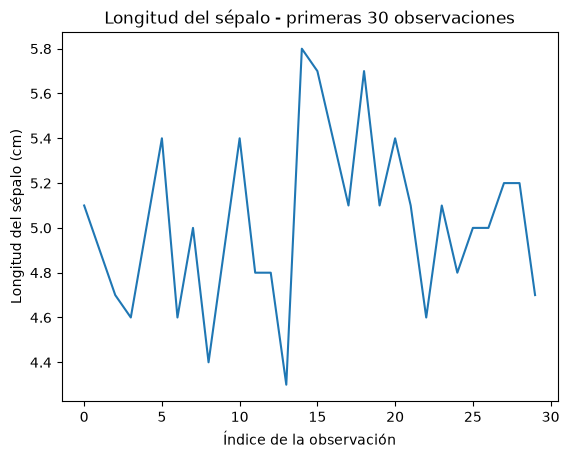

In [ ]:
plt.plot(df.index[:30], df["sepal_length_cm"].iloc[:30])

plt.title("Longitud del sépalo - primeras 30 observaciones")
plt.xlabel("Índice de la observación")
plt.ylabel("Longitud del sépalo (cm)")

plt.show()

# La línea representa cómo varía la longitud del sépalo entre las
# primeras 30 observaciones del dataset. El orden corresponde al índice
# de las filas del archivo y no representa necesariamente una secuencia temporal.

In [2]:
import matplotlib.pyplot as plt

In [4]:
import pandas as pd

df = pd.read_csv(r"C:\Users\dpuse\OneDrive\Documentos\datascience-g8\iris_dataset.csv")

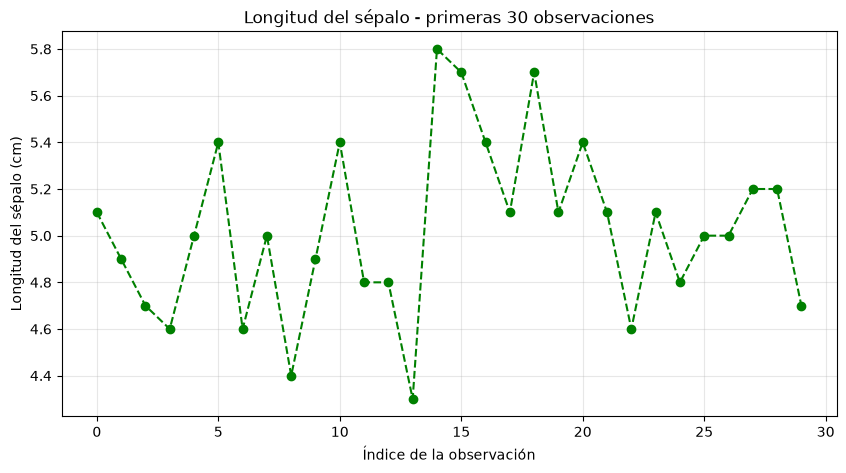

In [6]:
# 3. Línea: personalización
plt.figure(figsize=(10, 5))

plt.plot(
    df.index[:30],
    df["sepal_length_cm"].iloc[:30],
    marker="o",
    linestyle="--",
    color="green"
)

plt.title("Longitud del sépalo - primeras 30 observaciones")
plt.xlabel("Índice de la observación")
plt.ylabel("Longitud del sépalo (cm)")
plt.grid(alpha=0.3)

plt.show()

In [7]:
# 4: Barras — promedio por especie.

promedio_sepalo = df.groupby("species")["sepal_length_cm"].mean()

promedio_sepalo

species
setosa        5.006
versicolor    5.936
virginica     6.588
Name: sepal_length_cm, dtype: float64

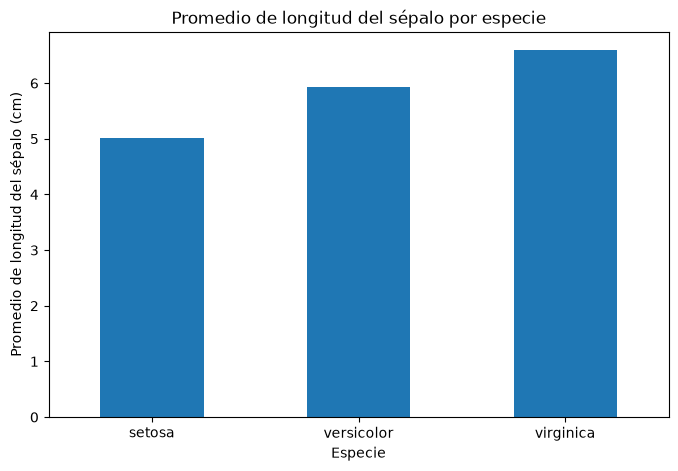

In [8]:
plt.figure(figsize=(8, 5))

promedio_sepalo.plot(kind="bar")

plt.title("Promedio de longitud del sépalo por especie")
plt.xlabel("Especie")
plt.ylabel("Promedio de longitud del sépalo (cm)")
plt.xticks(rotation=0)

plt.show()

In [9]:
# 5. Barras horizontales

promedio_petalo = df.groupby("species")["petal_length_cm"].mean().sort_values()

promedio_petalo

species
setosa        1.462
versicolor    4.260
virginica     5.552
Name: petal_length_cm, dtype: float64

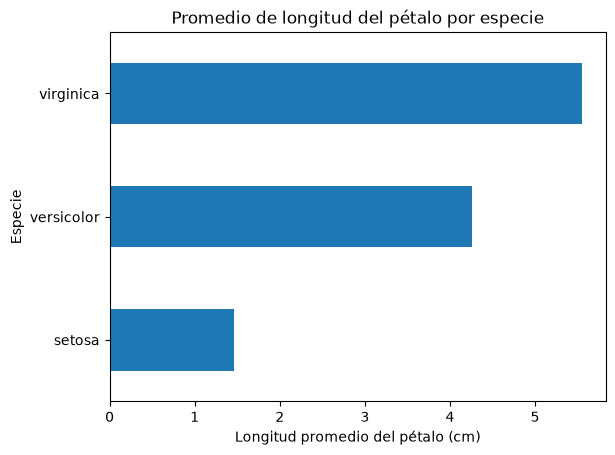

In [10]:
promedio_petalo.plot(kind="barh")

plt.title("Promedio de longitud del pétalo por especie")
plt.xlabel("Longitud promedio del pétalo (cm)")
plt.ylabel("Especie")

plt.show()

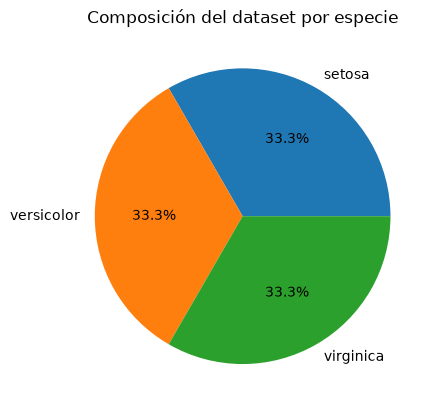

In [ ]:
# 6. Pastel: composición del dataset

conteo_especies = df["species"].value_counts()

conteo_especies

conteo_especies.plot(
    kind="pie",
    autopct="%.1f%%"
)

plt.title("Composición del dataset por especie")
plt.ylabel("")

plt.show()


# El dataset está balanceado, ya que las tres especies tienen
# la misma cantidad de observaciones y cada una representa
# aproximadamente el 33.3% del total.

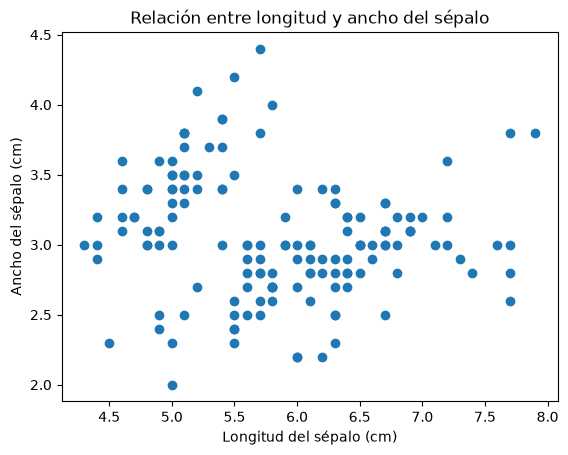

In [ ]:
# 7. Dispersión: sépalo

plt.scatter(
    df["sepal_length_cm"],
    df["sepal_width_cm"]
)

plt.title("Relación entre longitud y ancho del sépalo")
plt.xlabel("Longitud del sépalo (cm)")
plt.ylabel("Ancho del sépalo (cm)")

plt.show()

# No se observa una relación lineal muy clara entre la longitud
# y el ancho del sépalo. Los puntos presentan bastante dispersión.

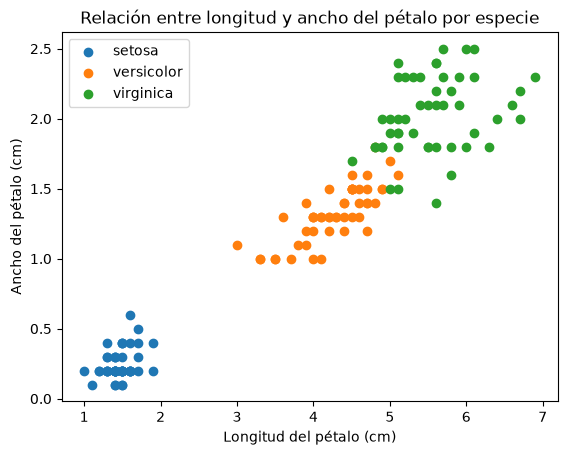

In [13]:
# 8. Dispersión por especie

for especie, grupo in df.groupby("species"):
    plt.scatter(
        grupo["petal_length_cm"],
        grupo["petal_width_cm"],
        label=especie
    )

plt.title("Relación entre longitud y ancho del pétalo por especie")
plt.xlabel("Longitud del pétalo (cm)")
plt.ylabel("Ancho del pétalo (cm)")
plt.legend()

plt.show()

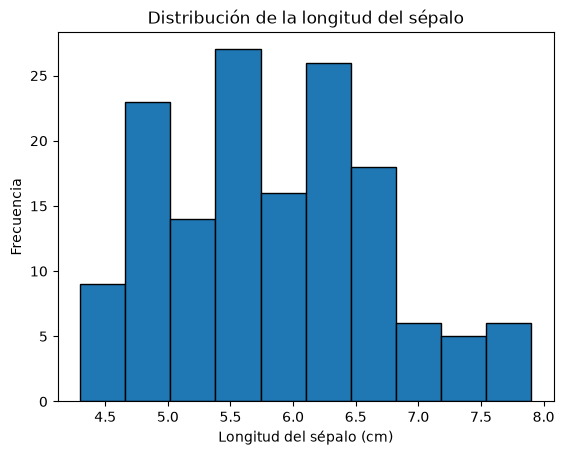

In [ ]:
# 9. Histograma: longitud del sépalo

plt.hist(
    df["sepal_length_cm"],
    bins=10,
    edgecolor="black"
)

plt.title("Distribución de la longitud del sépalo")
plt.xlabel("Longitud del sépalo (cm)")
plt.ylabel("Frecuencia")

plt.show()

# La mayor parte de las observaciones se concentra en los valores
# intermedios de longitud del sépalo, mientras que existen menos
# observaciones en los valores más bajos y más altos.

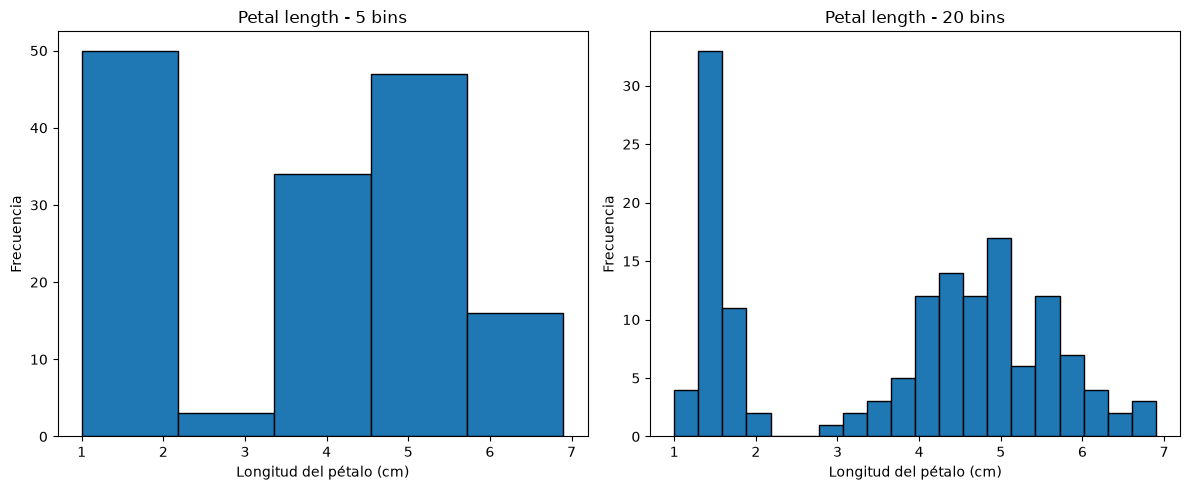

In [ ]:
# 10. Histograma y bins

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].hist(df["petal_length_cm"], bins=5, edgecolor="black")
ax[0].set_title("Petal length - 5 bins")
ax[0].set_xlabel("Longitud del pétalo (cm)")
ax[0].set_ylabel("Frecuencia")

ax[1].hist(df["petal_length_cm"], bins=20, edgecolor="black")
ax[1].set_title("Petal length - 20 bins")
ax[1].set_xlabel("Longitud del pétalo (cm)")
ax[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

# Con 5 bins se observa una distribución más general y resumida.
# Con 20 bins se aprecia mayor detalle y variación en los datos,
# aunque el gráfico también puede verse más fragmentado.

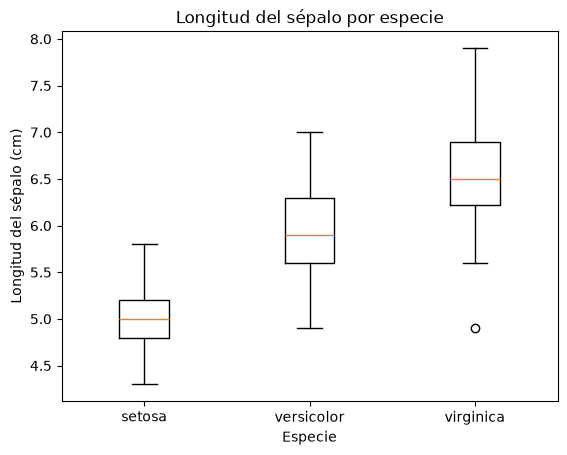

In [16]:
# 11. Boxplot por especie

especies = df["species"].unique()
especies

datos_boxplot = [
    df[df["species"] == especie]["sepal_length_cm"]
    for especie in especies
]

plt.boxplot(datos_boxplot, tick_labels=especies)

plt.title("Longitud del sépalo por especie")
plt.xlabel("Especie")
plt.ylabel("Longitud del sépalo (cm)")

plt.show()

# Las medianas de longitud del sépalo varían entre especies.
# Setosa presenta valores más bajos, mientras que virginica
# presenta los valores más altos.

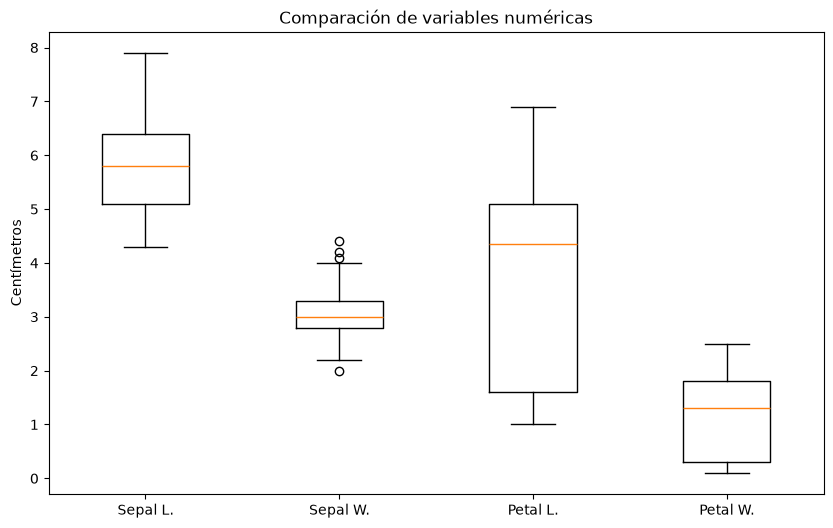

In [ ]:
# 12. Boxplot de variables numéricas

variables = [
    "sepal_length_cm",
    "sepal_width_cm",
    "petal_length_cm",
    "petal_width_cm"
]

plt.figure(figsize=(10, 6))

plt.boxplot(
    [df[columna] for columna in variables],
    tick_labels=["Sepal L.", "Sepal W.", "Petal L.", "Petal W."]
)

plt.title("Comparación de variables numéricas")
plt.ylabel("Centímetros")

plt.show()

# Se observa un problema de escala, ya que algunas variables presentan
# rangos mucho mayores que otras. Por ejemplo, sepal_length_cm alcanza
# valores mayores que petal_width_cm, dificultando su comparación directa.

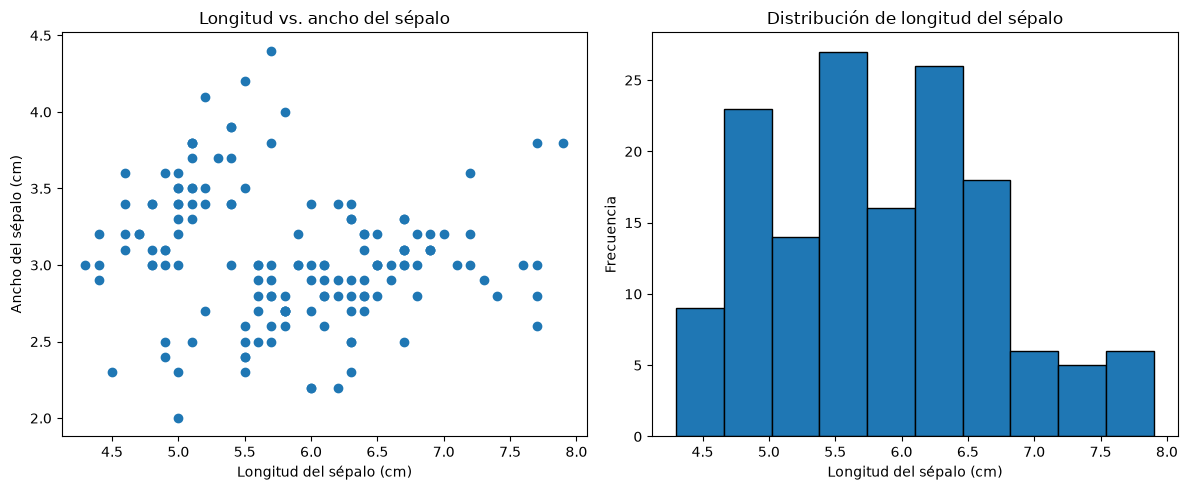

In [18]:
# 13. Subplots 1x2

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(
    df["sepal_length_cm"],
    df["sepal_width_cm"]
)

ax[0].set_title("Longitud vs. ancho del sépalo")
ax[0].set_xlabel("Longitud del sépalo (cm)")
ax[0].set_ylabel("Ancho del sépalo (cm)")


ax[1].hist(
    df["sepal_length_cm"],
    bins=10,
    edgecolor="black"
)

ax[1].set_title("Distribución de longitud del sépalo")
ax[1].set_xlabel("Longitud del sépalo (cm)")
ax[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

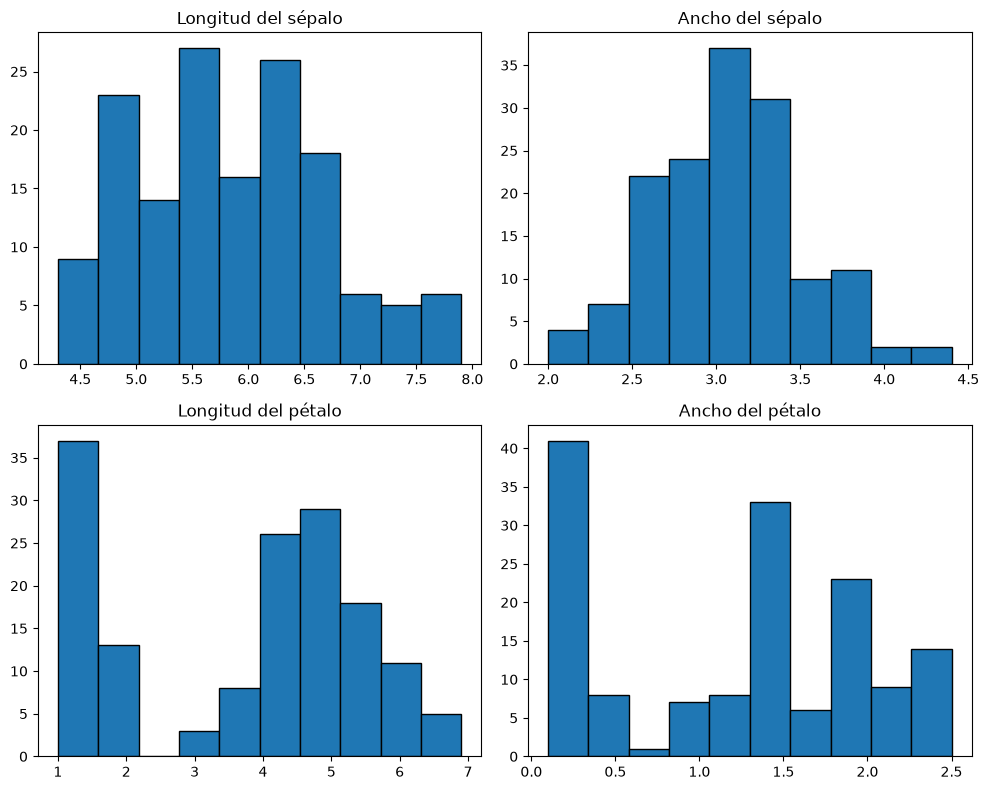

In [19]:
# 14. Subplots 2x2

fig, ax = plt.subplots(2, 2, figsize=(10, 8))

ax[0, 0].hist(df["sepal_length_cm"], bins=10, edgecolor="black")
ax[0, 0].set_title("Longitud del sépalo")

ax[0, 1].hist(df["sepal_width_cm"], bins=10, edgecolor="black")
ax[0, 1].set_title("Ancho del sépalo")

ax[1, 0].hist(df["petal_length_cm"], bins=10, edgecolor="black")
ax[1, 0].set_title("Longitud del pétalo")

ax[1, 1].hist(df["petal_width_cm"], bins=10, edgecolor="black")
ax[1, 1].set_title("Ancho del pétalo")

plt.tight_layout()
plt.show()

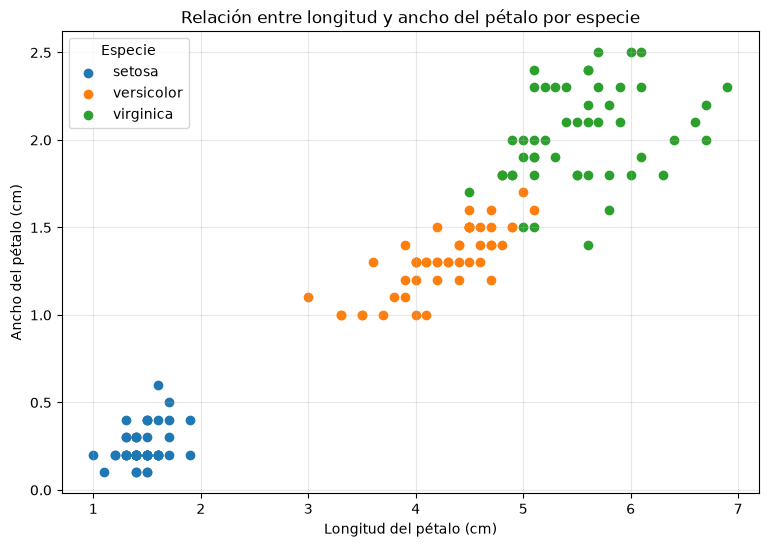

In [20]:
# 15. Leyendas y etiquetas

plt.figure(figsize=(9, 6))

for especie, grupo in df.groupby("species"):
    plt.scatter(
        grupo["petal_length_cm"],
        grupo["petal_width_cm"],
        label=especie
    )

plt.title("Relación entre longitud y ancho del pétalo por especie")
plt.xlabel("Longitud del pétalo (cm)")
plt.ylabel("Ancho del pétalo (cm)")
plt.legend(title="Especie")
plt.grid(alpha=0.3)

plt.show()

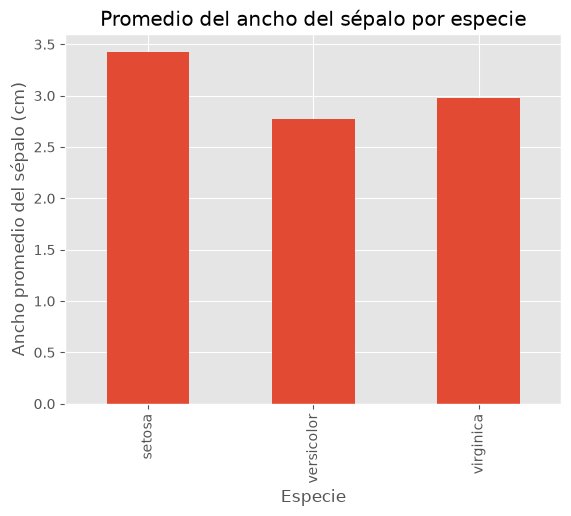

In [21]:
# 16. Estilos

promedio_ancho_sepalo = df.groupby("species")["sepal_width_cm"].mean()

plt.style.use("ggplot")

promedio_ancho_sepalo.plot(kind="bar")

plt.title("Promedio del ancho del sépalo por especie")
plt.xlabel("Especie")
plt.ylabel("Ancho promedio del sépalo (cm)")

plt.show()

plt.style.use("default")

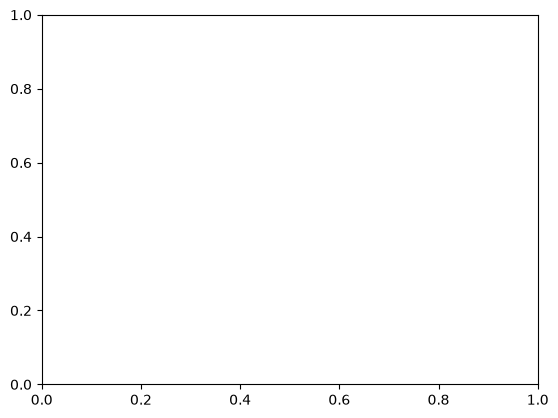

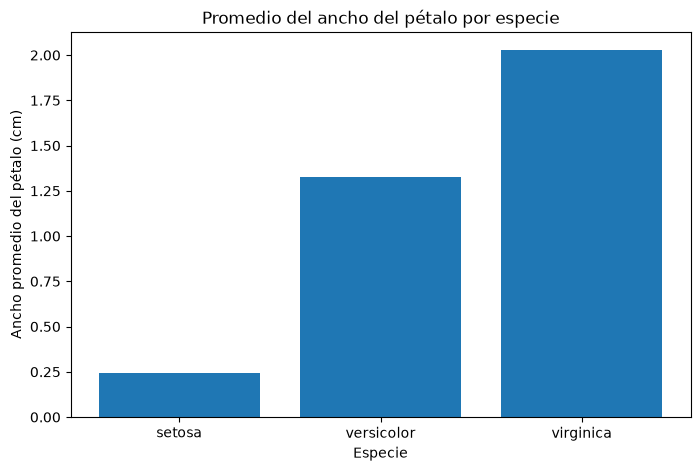

In [22]:
# 17. POO: Figure y Axes

fig, ax = plt.subplots()

promedio_petalo_ancho = df.groupby("species")["petal_width_cm"].mean()

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    promedio_petalo_ancho.index,
    promedio_petalo_ancho.values
)

ax.set_title("Promedio del ancho del pétalo por especie")
ax.set_xlabel("Especie")
ax.set_ylabel("Ancho promedio del pétalo (cm)")

plt.show()

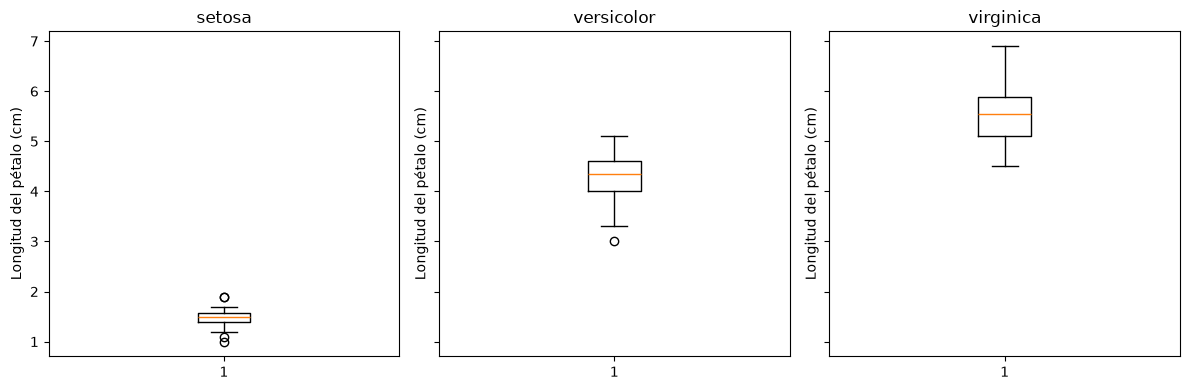

In [23]:
# 18. POO: múltiples Axes

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

especies = df["species"].unique()

for ax, especie in zip(axes, especies):
    datos = df[df["species"] == especie]["petal_length_cm"]

    ax.boxplot(datos)
    ax.set_title(especie)
    ax.set_ylabel("Longitud del pétalo (cm)")

plt.tight_layout()
plt.show()

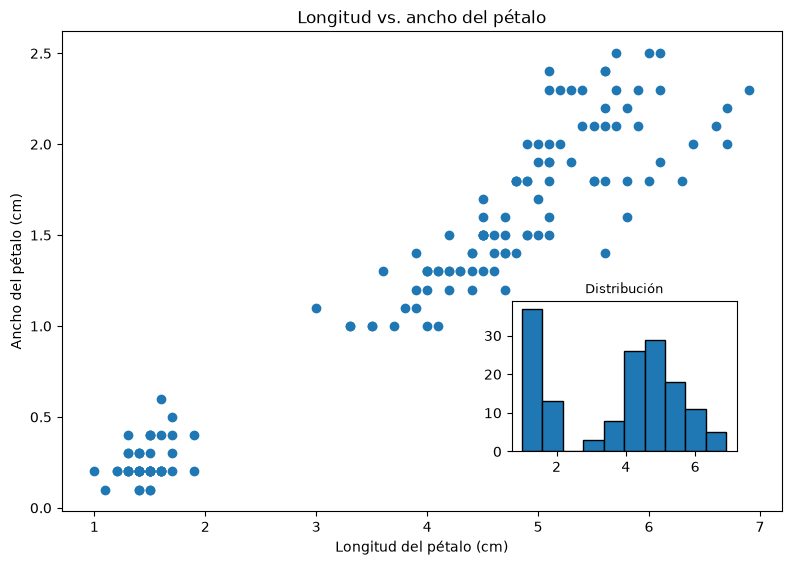

In [24]:
# 19. Gráfico principal + gráfico insertado

fig = plt.figure(figsize=(9, 6))

# Gráfico principal
ax_principal = fig.add_axes([0.1, 0.1, 0.8, 0.8])

ax_principal.scatter(
    df["petal_length_cm"],
    df["petal_width_cm"]
)

ax_principal.set_title("Longitud vs. ancho del pétalo")
ax_principal.set_xlabel("Longitud del pétalo (cm)")
ax_principal.set_ylabel("Ancho del pétalo (cm)")

# Gráfico insertado
ax_insertado = fig.add_axes([0.6, 0.2, 0.25, 0.25])

ax_insertado.hist(
    df["petal_length_cm"],
    bins=10,
    edgecolor="black"
)

ax_insertado.set_title("Distribución", fontsize=9)

plt.show()

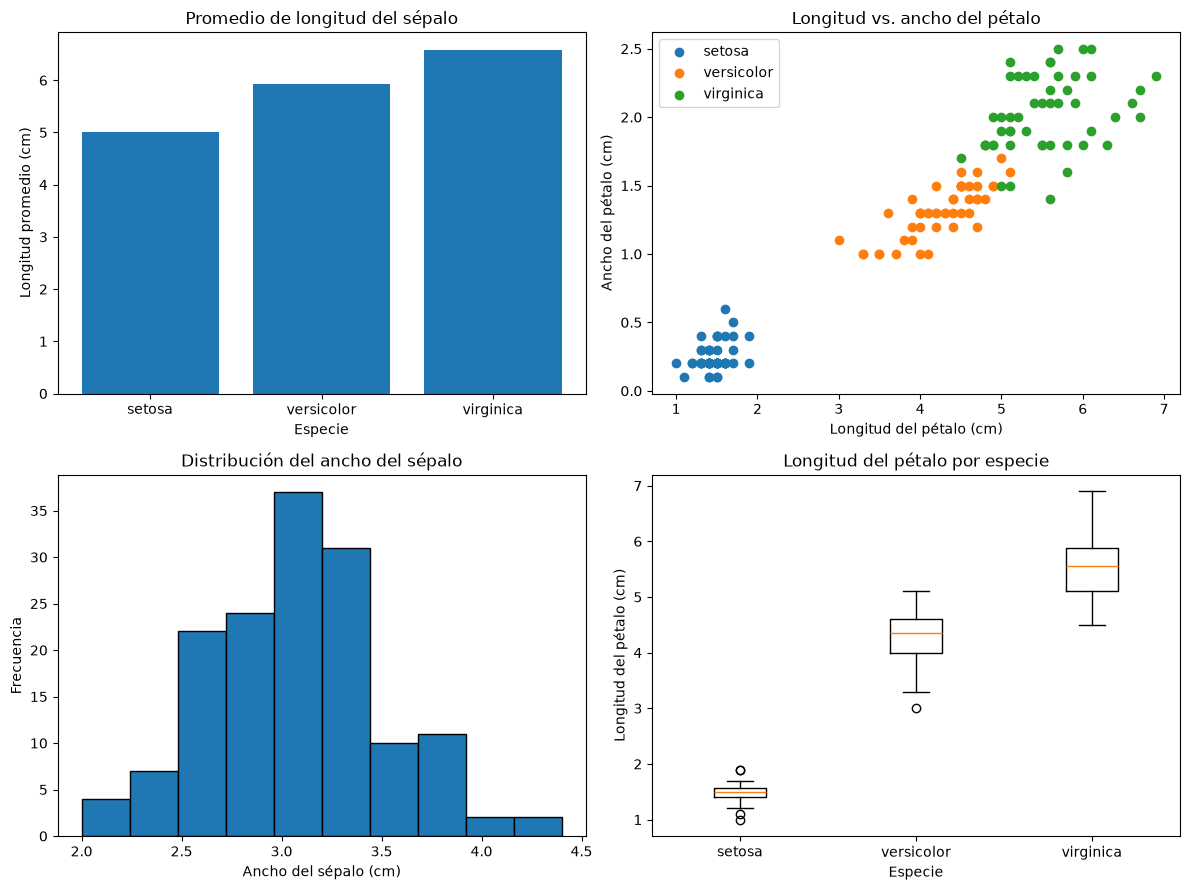

In [25]:
# 20. Mini dashboard final

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# 1. Barras: promedio longitud del sépalo por especie
promedio_sepalo = df.groupby("species")["sepal_length_cm"].mean()

axes[0, 0].bar(
    promedio_sepalo.index,
    promedio_sepalo.values
)

axes[0, 0].set_title("Promedio de longitud del sépalo")
axes[0, 0].set_xlabel("Especie")
axes[0, 0].set_ylabel("Longitud promedio (cm)")


# 2. Scatter: longitud vs ancho del pétalo por especie
for especie, grupo in df.groupby("species"):
    axes[0, 1].scatter(
        grupo["petal_length_cm"],
        grupo["petal_width_cm"],
        label=especie
    )

axes[0, 1].set_title("Longitud vs. ancho del pétalo")
axes[0, 1].set_xlabel("Longitud del pétalo (cm)")
axes[0, 1].set_ylabel("Ancho del pétalo (cm)")
axes[0, 1].legend()


# 3. Histograma del ancho del sépalo
axes[1, 0].hist(
    df["sepal_width_cm"],
    bins=10,
    edgecolor="black"
)

axes[1, 0].set_title("Distribución del ancho del sépalo")
axes[1, 0].set_xlabel("Ancho del sépalo (cm)")
axes[1, 0].set_ylabel("Frecuencia")


# 4. Boxplot longitud del pétalo por especie
especies = df["species"].unique()

datos_boxplot = [
    df[df["species"] == especie]["petal_length_cm"]
    for especie in especies
]

axes[1, 1].boxplot(
    datos_boxplot,
    tick_labels=especies
)

axes[1, 1].set_title("Longitud del pétalo por especie")
axes[1, 1].set_xlabel("Especie")
axes[1, 1].set_ylabel("Longitud del pétalo (cm)")


plt.tight_layout()
plt.show()